In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap, Normalize
import os, re
import codecs, warnings
from scipy import optimize, constants as const
from scipy.optimize import curve_fit
import uncertainties
from uncertainties import ufloat, unumpy

colors = ["red","darkorange","gold","lawngreen","lightseagreen","blueviolet","indigo"][::-1]
cmap = LinearSegmentedColormap.from_list("mycmap",colors)
num = 36

In [3]:
q = 23e6#m-1
a = 0.25e-6#m
π = np.pi

# def f2msd(f,q=23,d=3):
#     return -2*d/q**2 * unumpy.log(f)
def f2msd(f,q=23e6,d=3):
    return -2*d/q**2 * np.log(f)

def sort_files(filename):
    """sort files of cooling by measurement order"""
    files = np.empty((180,4))
    for i in range(1,181):
        file = filename.format(i)
        files[i-1,0] = i
        with open(file) as f:
            for line in f:
                if ".nsz" in line:
                    match = re.search(r'_(\d+)\.nsz', line)
                    files[i-1,1] = int(match.group(1))
                if "Temperature of the Holder" in line:
                    T = float(line.split(",")[1])
                    files[i-1,2] = T
                if "Count Rate" in line:
                    c = float(line.split(",")[1])
                    files[i-1,3] = c
    return files[np.argsort(files[:, 1])]

def get_g1(file):
    """get autocorrelation function from file"""
    with open(file) as f:
        for line in f:
            if "Correlation g1(T)" in line:
                data = np.loadtxt(f, delimiter=",", skiprows=0)
    return data[:,1]

def get_cooling(files, name):
    """get all data of one cooling, 
    returns a matrix (36x5x36) corresponding to (T, repeat, g1)"""
    cool = np.zeros((36,5,36))
    for i,n in enumerate(files[::,0]):
        file = name.format(int(n))
        data = get_g1(file)
        cool[i//5, i%5, :] = data
    return cool

In [4]:
def mmGp(ω, k, η):
    '''Elastic modulus of the Maxwell Model'''
    τ = η/k
    return k * (
        τ**2 * ω**2
    )/(
        1 + τ**2 * ω**2
    )
def mmGpp(ω, k, η):
    '''Viscous modulus of the Maxwell Model'''
    τ = η/k
    return k * (
        τ * ω
    )/(
        1 + τ**2 * ω**2
    )
def mmtandelta(ω, k, η):
    '''Loss tangent of the Maxwell Model'''
    τ = η/k
    return 1/(τ * ω)

def mmJ(t, k, η):
    '''Creep compliance of the Maxwell Model'''
    return 1/k + t/η

def jsGp(ω, k, η, ηs):
    '''Elastic modulus of the Johnson-Segalman model'''
    return mmGp(ω, k, η)
    
def jsGpp(ω, k, η, ηs):
    '''Viscous modulus of the Johnson-Segalman model'''
    return mmGpp(ω, k, η) + ηs*ω

def jstandelta(ω, k, η, ηs):
    '''Loss tangent of the Johnson-Segalman model'''
    return mmtandelta(ω, k, η) + ηs*ω / mmGp(ω, k, η)

def jsJ(t, k, η, ηs):
    '''Creep compliance of the Johnson-Segalman model'''
    return t/(η+ηs) + 1/k * (η/(η+ηs))**2 * (1 - np.exp(-k*(1/η + 1/ηs)*t))


In [5]:
Dt = np.array([1.00000e+00, 1.40000e+00, 1.90000e+00, 2.60000e+00, 3.60000e+00,
       5.00000e+00, 6.90000e+00, 9.50000e+00, 1.31000e+01, 1.81000e+01,
       2.50000e+01, 3.45000e+01, 4.76000e+01, 6.57000e+01, 9.07000e+01,
       1.25200e+02, 1.72800e+02, 2.38500e+02, 3.29200e+02, 4.54400e+02,
       6.27200e+02, 8.65700e+02, 1.19490e+03, 1.64930e+03, 2.27650e+03,
       3.14220e+03, 4.33710e+03, 5.98640e+03, 8.26290e+03, 1.14051e+04,
       1.57422e+04, 2.17286e+04, 2.99915e+04, 4.13966e+04, 5.71388e+04,
       7.88674e+04])*1e-6  #s

In [8]:
os.chdir(r"C:\Users\ajiye\Documents\DLS\Y4")
files = np.empty((180,4))

name = "cooling_1/Y16SE4-1mM-NP500nm-0.1pct-cooling1_{:03d}.csv"
files = sort_files(name)
cool1 = get_cooling(files, name)
T1 = np.reshape(files[:,2],(36,5))
c1 = np.reshape(files[:,3],(36,5))

name = "cooling_2/Y16SE4-1mM-NP500nm-0.1pct-cooling2_{:03d}.csv"
files = sort_files(name)
cool2 = get_cooling(files, name)
T2 = np.reshape(files[:,2],(36,5))
c2 = np.reshape(files[:,3],(36,5))

name = "cooling_3/Y16SE4-1mM-NP500nm-0.1pct-cooling3_{:03d}.csv"
files = sort_files(name)
cool3 = get_cooling(files, name)
T3 = np.reshape(files[:,2],(36,5))
c3 = np.reshape(files[:,3],(36,5))

name = "cooling_4/Y16SE4-1mM-NP500nm-0.1pct-cooling4_{:03d}.csv"
files = sort_files(name)
cool4 = get_cooling(files, name)
T4 = np.reshape(files[:,2],(36,5))
c4 = np.reshape(files[:,3],(36,5))

name = "cooling_5/Y16SE4-1mM-NP500nm-0.1pct-cooling5_{:03d}.csv"
files = sort_files(name)
cool5 = get_cooling(files, name)
T5 = np.reshape(files[:,2],(36,5))
c5 = np.reshape(files[:,3],(36,5))

In [9]:
from scipy.interpolate import CubicSpline
water = np.loadtxt(f'C:/Users/ajiye/Documents/DLS/water.tsv', skiprows=1)
eta_w = CubicSpline(water[:,0], water[:,1]*1e-3)

C:\Users\ajiye\AppData\Local\Temp\ipykernel_3216\3948433152.py:8: RuntimeWarning: divide by zero encountered in log
  return -2*d/q**2 * np.log(f)


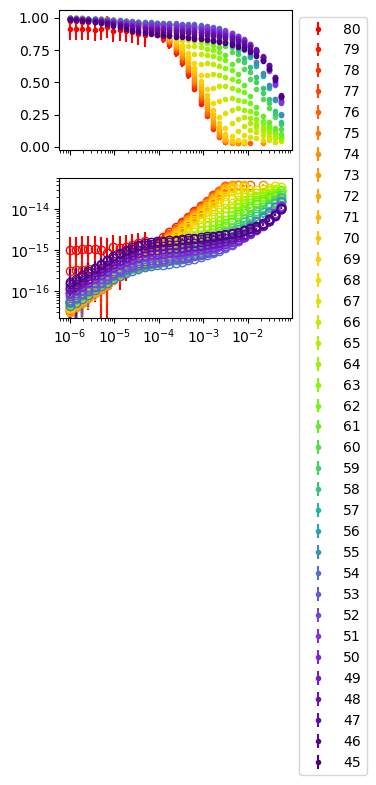

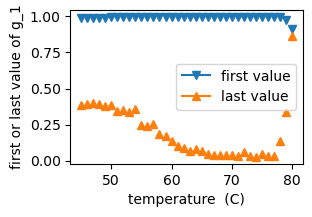

In [10]:
colors = ["red","darkorange","gold","lawngreen","lightseagreen","blueviolet","indigo"][::-1]
cmap = LinearSegmentedColormap.from_list("mycmap",colors)
num = 36
gradient = cmap(np.linspace(0, 1, num))[::-1] 

fig3, ax3 = plt.subplots(2, 1, figsize=(3,4), sharex=True)
fig4, ax4 = plt.subplots(1, 1, figsize=(3,2))

coolings = [cool1, cool2, cool3, cool4, cool5]
counts = [c1, c2, c3, c4, c5]
labels = list(range(80,44,-1))

G1 = np.empty((36,36))
MSD = np.empty((36,36))
err_minus = np.empty((36,36))
err_plus = np.empty((36,36))

for T in range(0,36,1):
    # print(labels[T])
    # moyennage g1 par temperature (num de cooling et num mesure confondus)
    s = 0
    sum_count = 0
    for i, cooling in enumerate(coolings):
        count = counts[i] 
        sum_count += np.sum(count[T,:])
        for j in range(5):
            g2 = cooling[T,j,:]**2 + 1
            s += (g2 * count[T,j])
    g1 = np.sqrt(s/sum_count - 1)
    G1[T,:] = g1
    err_f = 1-g1[0]
    select = np.where(g1>10*err_f)[0]
    ax3[0].errorbar(Dt[select], g1[select], yerr=err_f, color=gradient[T], marker='.', linestyle='None', label=labels[T])
    ax4.plot(labels[T], g1[select][0], marker='v', color='tab:blue', label='first value' if T == 0 else "")
    ax4.plot(labels[T], g1[select][-1], marker='^', color='tab:orange', label='last value' if T == 0 else "")
    
    # calcul msd avec erreur
    msd = f2msd(g1, q)
    MSD[T,:] = msd
    
    err_minus_msd = np.maximum(0, msd - f2msd(g1 + err_f, q))
    err_plus_msd = f2msd(np.maximum(0, g1 - err_f), q) - msd
    
    err_minus[T,:] = err_minus_msd
    err_plus[T,:] = err_plus_msd
    ax3[1].errorbar(
        Dt[select], msd[select], yerr=(err_minus_msd[select], err_plus_msd[select]),#msd[0],
        ls='none', marker='o', mfc='none', zorder=1.5, color=gradient[T]
    )

ax3[1].set_xscale('log')
ax3[1].set_yscale('log')
ax3[0].legend(loc='upper left', bbox_to_anchor=(1, 1))

ax4.set_xlabel('temperature  (C)')
ax4.set_ylabel('first or last value of g_1')
ax4.legend()

temperature 79 C
water viscosity = 0.00036+/-0.00000
fit newtonien: eta = (4.24+/-0.00)e-04 Pa.s
0.45+/-0.32 0.00010+/-0.00005
fit JS: k = 0.45+/-0.32, eta = 0.00010+/-0.00005
temperature 78 C
water viscosity = 0.00036+/-0.00000
fit newtonien: eta = (4.51+/-0.00)e-04 Pa.s
1.8+/-0.5 (9.3+/-0.4)e-05
fit JS: k = 1.8+/-0.5, eta = (9.3+/-0.4)e-05
temperature 77 C
water viscosity = 0.00037+/-0.00000
fit newtonien: eta = (7.05+/-0.00)e-04 Pa.s
2.3+/-0.9 0.000107+/-0.000006
fit JS: k = 2.3+/-0.9, eta = 0.000107+/-0.000006
temperature 76 C
water viscosity = 0.00037+/-0.00000
fit newtonien: eta = (1.31+/-0.00)e-03 Pa.s
2.5+/-0.8 0.000120+/-0.000006
fit JS: k = 2.5+/-0.8, eta = 0.000120+/-0.000006
temperature 75 C
water viscosity = 0.00038+/-0.00000
fit newtonien: eta = (5.24+/-0.00)e-04 Pa.s
2.6+/-0.4 0.0001296+/-0.0000027
fit JS: k = 2.6+/-0.4, eta = 0.0001296+/-0.0000027
temperature 74 C
water viscosity = 0.00038+/-0.00000
fit newtonien: eta = (2.03+/-0.00)e-03 Pa.s
3.0+/-1.4 0.000147+/-0.0000

(50.0, 82.95)

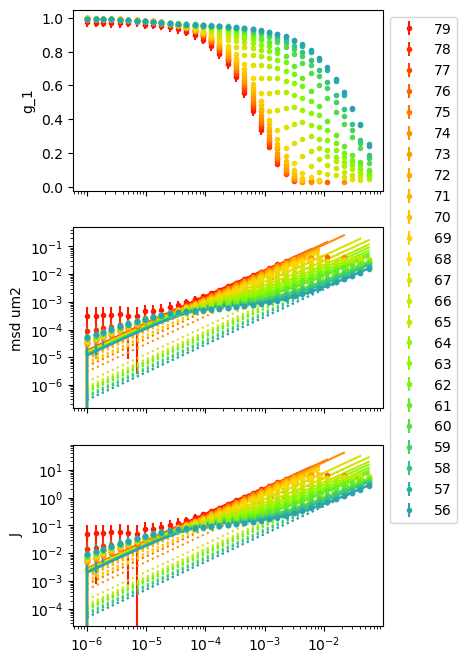

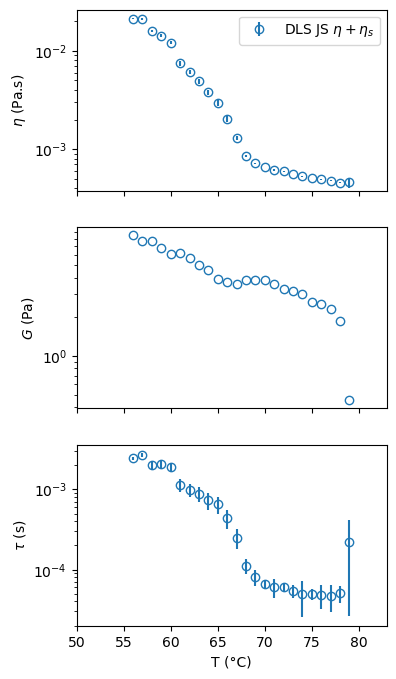

In [17]:
fig5, ax5 = plt.subplots(3, 1, figsize=(4,8), sharex=True)
fig4, ax4 = plt.subplots(3, 1, figsize=(4,8), sharex=True)
ax5[0].set_xscale('log')
ax5[1].set_yscale('log')
ax5[2].set_yscale('log')
ax5[0].set_ylabel('g_1')
ax5[1].set_ylabel('msd um2')
ax5[2].set_ylabel('J')

s = 0
sum_count = 0
paramsDLS = np.zeros((36,7))
k = uncertainties.ufloat(20,0)

for T in range(1,25,1):
    print(f'temperature {labels[T]} C')
    g1 = G1[T,:]
    msd = MSD[T,:]
    err_f = 1 - g1[0]
    err_msd_min = err_minus[T,:]
    err_msd_max = err_plus[T,:]
    # err_msd = (err_msd_min+err_msd_max)/2
    # print(err_msd_min - err_msd_max)
    select = np.where(g1>10*err_f)[0]
    ax5[0].errorbar(Dt[select], g1[select], yerr=err_f, 
                    color=gradient[T], marker='.', linestyle='None', label=labels[T])
    ax5[1].errorbar(Dt[select], 1e12*msd[select], yerr=(1e12*err_msd_min[select], 1e12*err_msd_max[select]), 
                    color=gradient[T], marker='.', linestyle='None', label=labels[T])
    # yerr=(err_minus[T,:], err_plus[T,:]),
    # Product of the diffusion coefficient and viscosity (independent of viscosity)
    D_eta_s = const.Boltzmann * const.convert_temperature(labels[T], 'C', 'K')/(6*π*a)   #SI unit
    J = -1/(q**2 * D_eta_s) * unumpy.log(unumpy.uarray(g1, err_f)) #SI unit
    ax5[2].errorbar(Dt[select], unumpy.nominal_values(J[select]), yerr=unumpy.std_devs(J[select]), 
                    color=gradient[T], marker='.', linestyle='None', label=labels[T])
    eta_s = ufloat(float(eta_w(labels[T])), 1e-7)   #SI unit Pa.s
    print(f'water viscosity = {eta_s:.2}')
    # fit newtonien
    popt, pcov = curve_fit(
        lambda t, eta: t / eta,
        Dt[select], #[0:10]
        unumpy.nominal_values(J[select]),
        p0 = eta_s.n
    )
    eta = ufloat(popt[0], pcov[0,0]) 
    print(f'fit newtonien: eta = {eta:.2e} Pa.s')
    ax5[1].plot(Dt[select], 6 * D_eta_s * Dt[select] / (eta.n * 1e-12), color=gradient[T], ls=':')
    ax5[2].plot(Dt[select], Dt[select] / eta.n, color=gradient[T], ls=':')
    # fit JS
    k = max(uncertainties.ufloat(20,0),k)

    popt, pcov = curve_fit(
            lambda t, k, eta: np.exp(-q**2 * D_eta_s * jsJ(t, k, eta, eta_s.n)),
            Dt[select],
            g1[select],
            p0 = [k.n, 0.015],
            bounds=[[0,0], [np.inf, np.inf]]
        )
    k, eta = uncertainties.correlated_values(popt, pcov)
    print(k, eta)
    ax5[1].plot(Dt[select], 6e12* D_eta_s * jsJ(Dt[select], k.n, eta.n, eta_s.n), color=gradient[T], ls='-')
    # if k.n<1 or k.n>1e5 or k.s>k.n/2:
    #     popt, pcov = curve_fit(
    #         lambda t, eta_s: np.log(6 * D_eta_s/eta_s * t),
    #         Dt[select],
    #         np.log(msd[select]),
    #         [eta_s.n]
    #     )
    #     eta = uncertainties.correlated_values(popt, pcov)[0] - eta_s
    #     k = uncertainties.ufloat(0,0)
    paramsDLS[T] = labels[T], k.n, eta.n, eta_s.n, k.s, max(0,eta.s-eta_s.s), eta_s.s
    print(f'fit JS: k = {k}, eta = {eta}')
    ax5[2].plot(Dt[select], jsJ(Dt[select], k.n, eta.n, eta_s.n), color=gradient[T], ls='-')

ax5[0].set_xscale('log')
ax5[1].set_yscale('log')
ax5[2].set_yscale('log')
ax5[0].legend(loc='upper left', bbox_to_anchor=(1, 1))

ax4[0].errorbar(
        paramsDLS[:,0], paramsDLS[:, 2]+paramsDLS[:, 3],
        paramsDLS[:, 5]+paramsDLS[:, 6],
        ls='none', marker='o', mfc='none',
        label=r'DLS JS $\eta+\eta_s$'
    )
ax4[1].errorbar(
        paramsDLS[:,0], paramsDLS[:, 1],
        ls='none', marker='o', mfc='none', label=r'DLS JS $k$'
    )
tau = unumpy.uarray(paramsDLS[:, 2], paramsDLS[:, 5])[paramsDLS[:, 1]>0] / unumpy.uarray(paramsDLS[:, 1], paramsDLS[:, 4])[paramsDLS[:, 1]>0]
ax4[2].errorbar(
        paramsDLS[paramsDLS[:, 1]>0,0],
        unumpy.nominal_values(tau),
        unumpy.std_devs(tau),
        ls='none', marker='o', mfc='none', label=r'DLS JS $\eta/k$'
    )

for ax in ax4:
    ax.set_yscale('log')
    # ax.axvline(Tmin, ls=':', color='k')
ax4[0].set_ylabel(r'$\eta$ (Pa.s)')
ax4[1].set_ylabel(r'$G$ (Pa)')
ax4[2].set_ylabel(r'$\tau$ (s)')
ax4[2].set_xlabel('T (°C)')
ax4[0].legend(loc='upper right')
ax4[0].set_xlim(50,)